In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

df = pd.read_csv('data.csv')
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

print("Shape:", df.shape)
print(df.head())
print(df.info())

Shape: (28132, 89)
   dst_port protocol  duration  total_bytes  total_packets  fwd_pkts  fwd_bytes  fwd_pkt_len_mean  fwd_pkt_len_std  fwd_pkt_len_min  fwd_pkt_len_max  fwd_iat_mean  fwd_iat_std  fwd_iat_min  \
0       443      TCP  0.414215         4391             18         9       1069          118.7778          96.0599             54.0            331.0      0.051777     0.060601     0.000052   
1       443      TCP  0.058407         4369             17         9       1101          122.3333          98.8849             54.0            331.0      0.007301     0.008833     0.000067   
2       443      TCP  0.038559         4261             15         8       1047          130.8750         101.7048             54.0            331.0      0.005508     0.008076     0.000184   
3       443      TCP  0.037885         4261             15         8       1047          130.8750         101.7048             54.0            331.0      0.005412     0.008064     0.000093   
4       443      TCP 

In [11]:
df = df[df["label"] != "dreambot"].reset_index(drop=True)
df = df[df["label"] != "minor_project"].reset_index(drop=True)


In [12]:
print(df['label'].value_counts())

label
emotet      13972
trickbot    10904
Name: count, dtype: int64


In [6]:
# Cell 2: Keep only your selected features
features = [
    "protocol",
    "duration",
    "total_bytes",
    "total_packets",
    "bytes_per_second",
    "packets_per_second",
    "pkt_len_mean",
    "pkt_len_std",
    "iat_mean",
    "iat_std",
    "burstiness",
    "burst_count",
    "is_complete_handshake",
    "has_tls",
    "tls_cipher_count",
    "tls_ext_count",
    "ja4_fingerprint",
    "ja4_tls_ver_num",
    "ja4_cipher_count",
    "ja4_ext_count",
    "ja4_sni_present",
    "ja4_has_alpn",
    "ja3_fingerprint",
    "dns_query_count",
    "dns_unique_queries",
    "http_request_count",
    "http_unique_hosts",
    "label"
]

missing_cols = [c for c in features if c not in df.columns]
print("Missing columns:", missing_cols)

df = df[features].copy()
print("New shape:", df.shape)
print(df.head())

Missing columns: []
New shape: (28132, 28)
  protocol  duration  total_bytes  total_packets  bytes_per_second  packets_per_second  pkt_len_mean  pkt_len_std  iat_mean   iat_std  burstiness  burst_count  is_complete_handshake  has_tls  \
0      TCP  0.414215         4391             18        10600.7750             43.4557      243.9444     361.0636  0.024366  0.048840      2.0045            1                      1        1   
1      TCP  0.058407         4369             17        74802.6778            291.0610      257.0000     368.1982  0.003650  0.007186      1.9686            1                      1        1   
2      TCP  0.038559         4261             15       110505.9779            389.0142      284.0667     383.9515  0.002754  0.006277      2.2790            1                      1        1   
3      TCP  0.037885         4261             15       112471.9546            395.9351      284.0667     383.9515  0.002706  0.006265      2.3151            1                      1

In [7]:
# Cell 3: Basic cleaning checks
print("Duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates()
print("After drop_duplicates:", df.duplicated().sum())

print("Missing values:")
print(df.isnull().sum().sort_values(ascending=False))

print("Label counts:")
print(df["label"].value_counts())
print("Label proportions:")
print(df["label"].value_counts(normalize=True).round(4))

Duplicate rows: 7
After drop_duplicates: 0
Missing values:
protocol                 0
duration                 0
total_bytes              0
total_packets            0
bytes_per_second         0
packets_per_second       0
pkt_len_mean             0
pkt_len_std              0
iat_mean                 0
iat_std                  0
burstiness               0
burst_count              0
is_complete_handshake    0
has_tls                  0
tls_cipher_count         0
tls_ext_count            0
ja4_fingerprint          0
ja4_tls_ver_num          0
ja4_cipher_count         0
ja4_ext_count            0
ja4_sni_present          0
ja4_has_alpn             0
ja3_fingerprint          0
dns_query_count          0
dns_unique_queries       0
http_request_count       0
http_unique_hosts        0
label                    0
dtype: int64
Label counts:
label
emotet           13972
trickbot         10904
minor_project     3190
dreambot            59
Name: count, dtype: int64
Label proportions:
label
emotet   

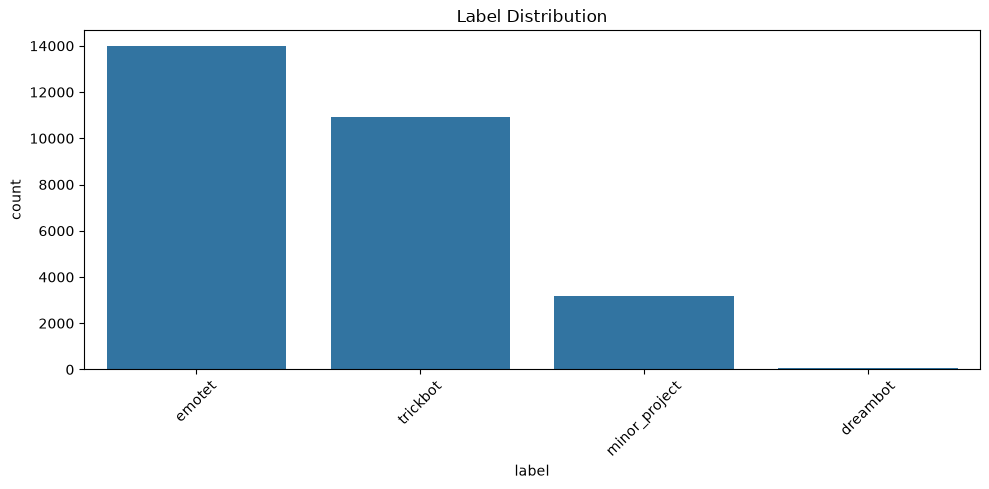

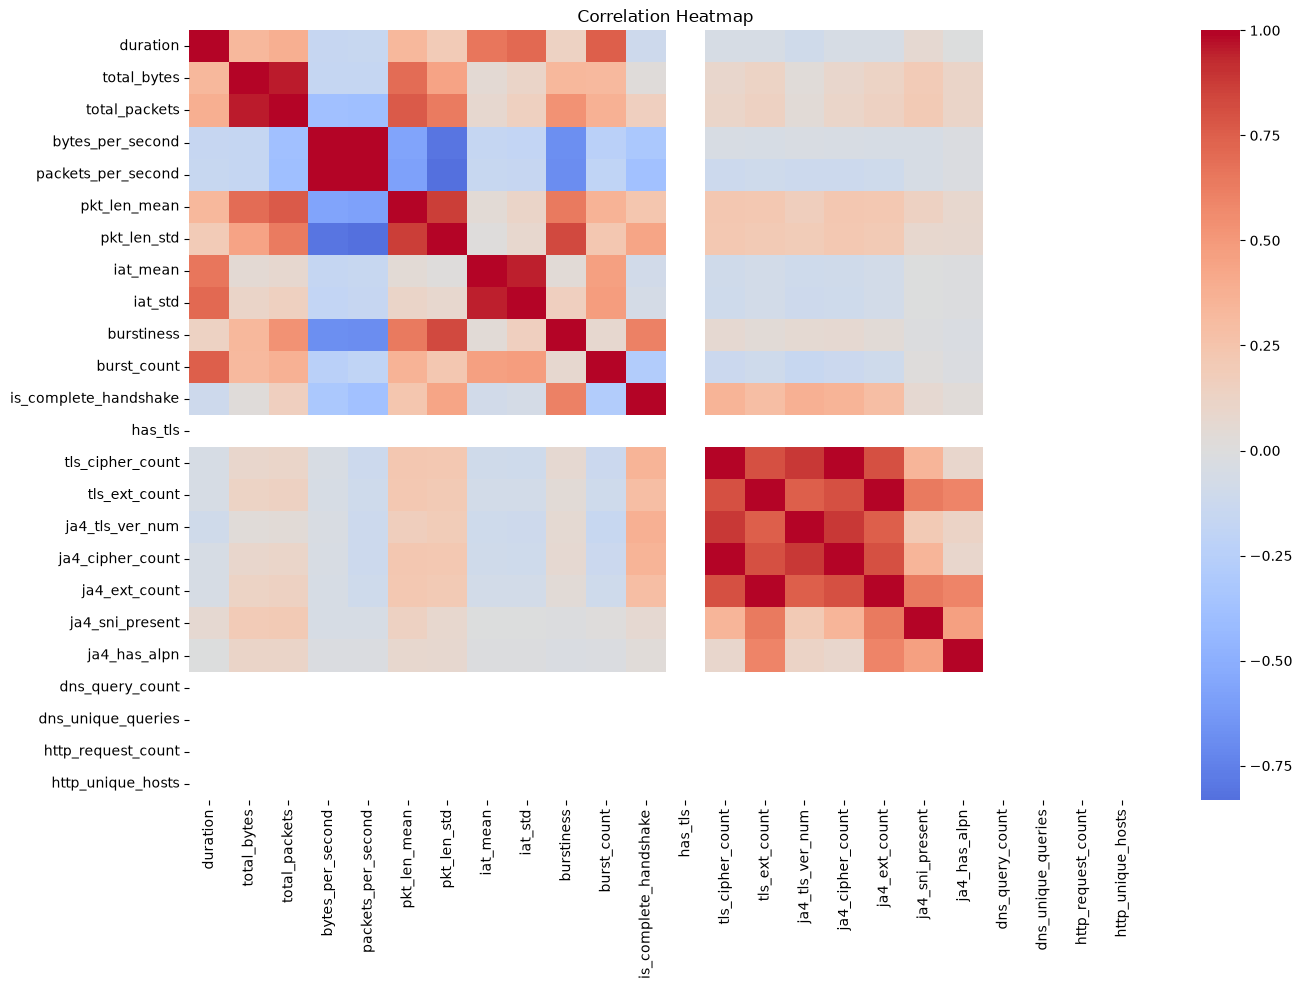

In [8]:
# Cell 4: EDA plots
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x="label", order=df["label"].value_counts().index)
plt.title("Label Distribution")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

plt.figure(figsize=(14, 10))
corr = df[numeric_cols].corr()
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

top_missing = df.isnull().sum().sort_values(ascending=False)
top_missing = top_missing[top_missing > 0]

if len(top_missing) > 0:
    plt.figure(figsize=(12, 5))
    top_missing.head(20).plot(kind="bar")
    plt.title("Top Missing Columns")
    plt.ylabel("Missing Count")
    plt.tight_layout()
    plt.show()

In [16]:
# ============================================================
# Cell 5 (structural JA4 encoding version)
# Labels used: emotet, trickbot  (2-class, matches your current data)
# ============================================================

import re

X = df.drop(columns=["label"]).copy()
y = df["label"].copy()

print("Label counts going into this cell:")
print(y.value_counts())

# --- Fill missing values (pandas-version-safe) ---
for col in X.columns:
    if pd.api.types.is_numeric_dtype(X[col]):
        X[col] = X[col].fillna(X[col].median())
    else:
        X[col] = X[col].fillna("unknown")

# --- Optional flags for sparse fingerprint fields ---
if "ja4_fingerprint" in X.columns:
    X["has_ja4"] = (X["ja4_fingerprint"] != "unknown").astype(int)
if "ja3_fingerprint" in X.columns:
    X["has_ja3"] = (X["ja3_fingerprint"] != "unknown").astype(int)


# ============================================================
# JA4 STRUCTURAL (character) ENCODING
# Splits t12i210300_b973bfd88a0e_c08b0bbc99a6 into its real parts
# instead of treating the whole string as one opaque ID.
# ============================================================

PROTOCOL_VOCAB = {"t": 0, "q": 1}
TLS_VERSION_VOCAB = {
    "13": 0, "12": 1, "11": 2, "10": 3,
    "s3": 4, "s2": 5, "s1": 6, "d3": 7, "d2": 8, "d1": 9, "00": 10,
}
ALPN_VOCAB = {"00": 0, "h1": 1, "h2": 2, "h3": 3, "ht": 4, "d2": 5}
N_HASH_BUCKETS = 256

def parse_ja4(fp: str) -> dict:
    if not isinstance(fp, str) or "_" not in fp or fp == "unknown":
        return None
    parts = fp.split("_")
    if len(parts) != 3 or len(parts[0]) < 10:
        return None
    a, b, c = parts
    return {
        "protocol": PROTOCOL_VOCAB.get(a[0], -1),
        "tls_version": TLS_VERSION_VOCAB.get(a[1:3], -1),
        "sni_present": 1 if a[3] == "d" else 0,
        "cipher_count": int(re.sub(r"\D", "", a[4:6]) or 0),
        "ext_count": int(re.sub(r"\D", "", a[6:8]) or 0),
        "alpn": ALPN_VOCAB.get(a[8:10], -1),
        "cipher_hash_bucket": int(b, 16) % N_HASH_BUCKETS if b else 0,
        "ext_hash_bucket": int(c, 16) % N_HASH_BUCKETS if c else 0,
    }

JA4_SUBFEATURES = [
    "ja4_protocol", "ja4_tls_version_parsed", "ja4_sni_present_parsed",
    "ja4_cipher_count_parsed", "ja4_ext_count_parsed", "ja4_alpn",
    "ja4_cipher_hash_bucket", "ja4_ext_hash_bucket",
]

if "ja4_fingerprint" in X.columns:
    parsed = X["ja4_fingerprint"].map(parse_ja4)
    for i, feat_name in enumerate(JA4_SUBFEATURES):
        key = list(parse_ja4.__annotations__) if False else None  # (no-op, keeps linters quiet)
    keys = ["protocol", "tls_version", "sni_present", "cipher_count",
            "ext_count", "alpn", "cipher_hash_bucket", "ext_hash_bucket"]
    for feat_name, key in zip(JA4_SUBFEATURES, keys):
        X[feat_name] = parsed.map(lambda p, k=key: p[k] if p else -1)

    # drop the raw string now that it's been decomposed
    X = X.drop(columns=["ja4_fingerprint"])
    print(f"ja4_fingerprint -> expanded into {len(JA4_SUBFEATURES)} structural features:")
    print(JA4_SUBFEATURES)

# --- JA3 stays as a plain ID (flat hash, no internal structure to parse) ---
UNKNOWN_ID = -1
def fit_id_map(series, mask):
    return {val: i for i, val in enumerate(sorted(series[mask].dropna().unique()))}
def apply_id_map(series, id_map):
    return series.map(lambda v: id_map.get(v, UNKNOWN_ID))

if "ja3_fingerprint" in X.columns:
    all_rows_mask = pd.Series(True, index=X.index)
    ja3_id_map = fit_id_map(X["ja3_fingerprint"], all_rows_mask)
    X["ja3_fingerprint"] = apply_id_map(X["ja3_fingerprint"], ja3_id_map)
    print(f"ja3_fingerprint -> {len(ja3_id_map)} unique IDs")

# protocol column (the flow-level one, not JA4's internal protocol byte)
if "protocol" in X.columns:
    X["protocol"] = pd.factorize(X["protocol"])[0]

# --- Encode target ---
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
y_categorical = tf.keras.utils.to_categorical(y_encoded)

print("\nClasses:", list(label_encoder.classes_))
print("X shape:", X.shape)
print("y shape:", y_categorical.shape)
print("\nFinal columns:", X.columns.tolist())

Label counts going into this cell:
label
emotet      13972
trickbot    10904
Name: count, dtype: int64
ja4_fingerprint -> expanded into 8 structural features:
['ja4_protocol', 'ja4_tls_version_parsed', 'ja4_sni_present_parsed', 'ja4_cipher_count_parsed', 'ja4_ext_count_parsed', 'ja4_alpn', 'ja4_cipher_hash_bucket', 'ja4_ext_hash_bucket']
ja3_fingerprint -> 8 unique IDs

Classes: ['emotet', 'trickbot']
X shape: (24876, 36)
y shape: (24876, 2)

Final columns: ['protocol', 'duration', 'total_bytes', 'total_packets', 'bytes_per_second', 'packets_per_second', 'pkt_len_mean', 'pkt_len_std', 'iat_mean', 'iat_std', 'burstiness', 'burst_count', 'is_complete_handshake', 'has_tls', 'tls_cipher_count', 'tls_ext_count', 'ja4_tls_ver_num', 'ja4_cipher_count', 'ja4_ext_count', 'ja4_sni_present', 'ja4_has_alpn', 'ja3_fingerprint', 'dns_query_count', 'dns_unique_queries', 'http_request_count', 'http_unique_hosts', 'has_ja4', 'has_ja3', 'ja4_protocol', 'ja4_tls_version_parsed', 'ja4_sni_present_parsed',

In [17]:
 
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
 
# --- Split: 70% train / 15% val / 15% test, stratified on the label ---
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_categorical, test_size=0.30, stratify=y_encoded, random_state=42
)
# split the remaining 30% into val/test halves
y_temp_labels = y_temp.argmax(axis=1)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp_labels, random_state=42
)
 
print("Split sizes:")
print("  train:", X_train.shape, y_train.shape)
print("  val:  ", X_val.shape, y_val.shape)
print("  test: ", X_test.shape, y_test.shape)
 
# --- Scale: fit ONLY on train, transform train/val/test ---
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)
 
# --- Reshape to 3D for Conv1D: (samples, n_features, 1 channel) ---
n_features = X_train_scaled.shape[1]
 
X_train_cnn = X_train_scaled.reshape(-1, n_features, 1)
X_val_cnn = X_val_scaled.reshape(-1, n_features, 1)
X_test_cnn = X_test_scaled.reshape(-1, n_features, 1)
 
print("\nReshaped for Conv1D:")
print("  X_train_cnn:", X_train_cnn.shape)
print("  X_val_cnn:  ", X_val_cnn.shape)
print("  X_test_cnn: ", X_test_cnn.shape)
 
num_classes = y_categorical.shape[1]
print("\nnum_classes:", num_classes, "| n_features (input length):", n_features)

Split sizes:
  train: (17413, 36) (17413, 2)
  val:   (3731, 36) (3731, 2)
  test:  (3732, 36) (3732, 2)

Reshaped for Conv1D:
  X_train_cnn: (17413, 36, 1)
  X_val_cnn:   (3731, 36, 1)
  X_test_cnn:  (3732, 36, 1)

num_classes: 2 | n_features (input length): 36
